# RAG, векторная база и память агента

На первом этапе ReAct-агент на дешёвой модели ходил за фактами в Википедию и на новостные сайты и отвечал верно на 44 процента свежих вопросов. Теперь кладём знания рядом: режем корпус на куски, считаем эмбеддинги, ищем сначала на numpy, потом в Milvus, собираем RAG-ответ с источниками, разбираем провалы и даём агенту память. В конце превращаем поиск в инструмент агента.

Тезис тот же: 

**Хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** 

Хотим ответить на вопрос: 

**Сколько стоит верный ответ, когда знания лежат в индексе, и сколько в этой цене занимает контекст.**


## Что нужно для воспроизведения

**Ключ** OpenRouter: локально файл `.env` в корне репозитория, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). 

**Данные**: в папке `data` в корне репозитория, в Kaggle датасет `ai-agent-events-data` и включённый Internet.

**Milvus** в Docker: в корне репозитория лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел [«Без Docker и в Kaggle»](../README.md#без-docker-и-в-kaggle).

In [1]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # ноутбук лежит в notebooks/
DATA = next((p for p in [ROOT / "data", Path("/kaggle/input/ai-agent-events-data"), Path("/kaggle/input/ai-agent-events-data/data")]
             if (p / "corpus_2026.jsonl").exists()), ROOT / "data")
IMG = ROOT / "img" / "02"
IMG.mkdir(parents=True, exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Спринт 1. Корпус и нарезка

Корпус - 50 страниц, 1,2 млн символов. Основа - 28 обзорных страниц английской Википедии про 2026 год, по ним составлены вопросы первого этапа. К ним добавлены 22 страницы для вопросов по интересам: статьи английской и русской Википедии, новости GEN и ESPN.

In [2]:
# Корпус собирает scripts/fetch_corpus.py: берёт готовые страницы из data/corpus_2026.jsonl и докачивает недостающие.
# Повторный запуск ничего не скачивает. В Kaggle скрипта нет, там корпус уже собран в датасете.
script = ROOT / "scripts" / "fetch_corpus.py"
if script.exists():
    !{sys.executable} {script}


страниц: 50 (скачано сейчас: 0), символов: 1222177, содержательных строк: 7388
вопросов с цитатой, найденной в корпусе: 154 из 155
  нет цитаты: fresh-6 [2026] August 26 – 2026 Nepal–Tibet floods: At least 1,130 people are killed and nearly 4,500 reported miss


### Проверка цитат

У каждого вопроса есть цитата `evidence`: строка из источника, в которой лежит ответ. По ней определяется верный кусок при подсчёте recall@k, поэтому цитата должна дословно находиться в корпусе. Скрипт выше проверяет это для всех вопросов и печатает те, у которых цитата не нашлась.

При первой сборке корпуса цитата не нашлась у 10 вопросов из 155. Девять из них исправлены так, что вопрос и эталонный ответ остались прежними:

| Вопрос | Почему цитата не нашлась | Что сделано |
|---|---|---|
| `fresh-130`, `131`, `136`, `138`, `142`, `145` | Цитата была пересказом, а не дословной строкой | Цитата заменена на дословную строку со страницы |
| `fresh-135` | Ответ есть только в таблице результатов | Цитата заменена на строку таблицы |
| `fresh-153` | Факт о падении на тулупе есть в статье о фигуристке, а не на странице турнира | Страница заменена на «Петросян, Аделия Тиграновна» |
| `fresh-154` | Баллов фигуристки нет на странице турнира | Страница заменена на «Alysa Liu» |
| `fresh-6` | Статью в Википедии обновили: вместо 4,500 пропавших теперь 6,650 | Не исправлен, во втором этапе не участвует |

На первом этапе цитата и страница не использовались: ответ агента сверялся только с эталоном. Поэтому правки не меняют его результаты. `fresh-6` оставлен как есть, чтобы не менять эталон и прогоны первого этапа, и во втором этапе участвуют 154 вопроса.

### Вопросы

Вопросы те же, что на первом этапе: 154 вопроса с коротким ответом, на которые Sonnet без инструментов почти не отвечает (`fresh-6` исключён, см. выше). У каждого есть цитата `evidence`, поэтому мы точно знаем, какой кусок верный, и считаем качество поиска без ручной разметки.

К ним добавлены 10 вопросов без ответа из `data/unanswerable_2026.jsonl`: по темам корпуса, но о том, чего в нём нет. Они двух видов, по пять:

- **ответа нет в корпусе, но он есть в мире** (`kind: not_in_corpus`). Например, сколько Chai Discovery привлекла в раунде Series C: в корпусе есть только статья про раунд Series B. Система, которая отвечает по корпусу, должна честно отказаться, а агент с живым поиском может найти ответ в интернете, поэтому у этих вопросов записан настоящий ответ со ссылкой на источник;
- **ответа нет нигде** (`kind: no_answer`): событие ещё не произошло или его не было, например премия Тьюринга за 2026 год. Честно отказаться должна любая система.

Так таблица отказов показывает сразу две вещи: где проходит граница базы знаний и выдумывает ли модель ответ, когда его нет.

In [3]:
def flat(text):
    return " ".join(re.sub(r"[^\w\s]", " ", str(text).lower()).split())

corpus = load_jsonl("corpus_2026.jsonl")
pages = {p["page"]: flat(p["text"]) for p in corpus}
tasks = [t for t in load_jsonl("fresh_2026.jsonl") if flat(t["evidence"])[:120] in pages.get(t["page"], "")]   # та же проверка, что в скрипте
unanswerable = load_jsonl("unanswerable_2026.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), {k: sum(t["kind"] == k for t in unanswerable) for k in ("not_in_corpus", "no_answer")}

(50, 1222177, 154, {'not_in_corpus': 5, 'no_answer': 5})

### Нарезка

Во всех источниках текст сохранён одинаково: каждый абзац, пункт списка и строка таблицы стоят на отдельной строке, заголовки разделов записаны как `== Раздел ==`. В обзорных страницах одна строка - одно событие, в статьях - абзац или строка таблицы.

Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По абзацам: одна строка - один кусок. Граница куска - конец абзаца: автор страницы уже сложил в один абзац один факт, и кусок не обрывает его на середине. Заголовок раздела едет с куском как метаданные. Строки из 40 символов и короче выбрасываются: это даты-подзаголовки вроде «August 26», подписи и пункты меню, сами по себе они ничего не значат. Длинные абзацы не делятся, но их немного: сколько кусков длиннее 800 символов, ячейка с гистограммой печатает под ней.

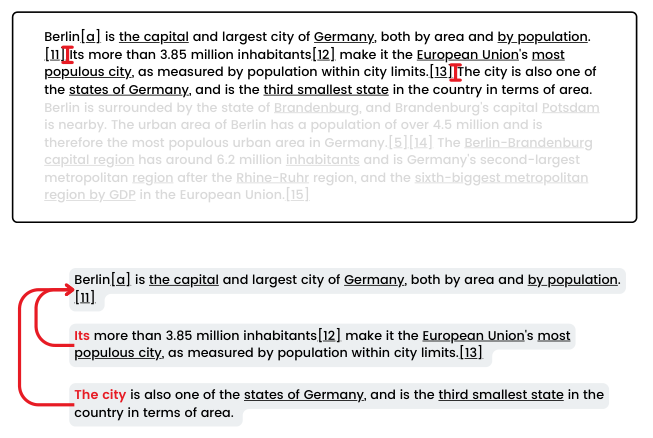

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [4]:
def chunk_lines(page):
    chunks, section = [], ""
    for line in page["text"].splitlines():
        line = " ".join(line.split())
        if line.startswith("="):
            section = line.strip('= ')
        elif len(line) > 40:
            chunks.append({"page": page["page"], "section": section, "url" : page["url"], "text": line})
    return chunks

In [5]:
def chunk_chars(page, size=400):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]

line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks), line_chunks[100]

(7282,
 3072,
 {'page': '2026',
  'section': 'April',
  'url': 'https://en.wikipedia.org/wiki/2026',
  'text': 'April 13 – 2026 Iran war: A blockade of Iranian ports by the United States takes effect, with President Trump warning that any Iranian vessels attempting to challenge it will be "immediately eliminated". Maritime authorities advise ships in the region to expect increased military activity and possible interception procedures.'})

In [6]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["page"] == task["page"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) == 2 else None

example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics? | ответ: 15 March
кусок 1: ...ic partnership agreement in the defense and energy sectors. 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest 
кусок 2: over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022. 19 March – Forme...


кусков по абзацам длиннее 800 символов: 80 из 7282 (1.1%)


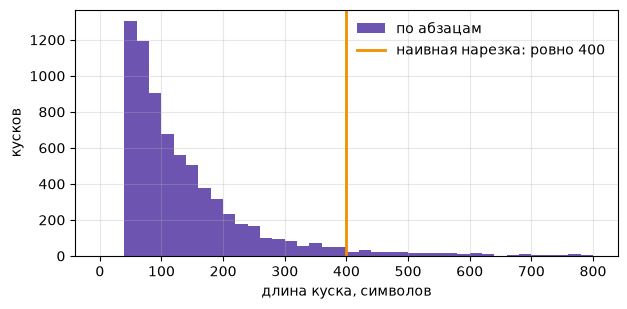

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по абзацам")
ax.axvline(400, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 400")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);
long = sum(len(c["text"]) > 800 for c in line_chunks)
print(f"кусков по абзацам длиннее 800 символов: {long} из {len(line_chunks)} ({long / len(line_chunks):.1%})")

## Спринт 2. Эмбеддинги и кэш

Эмбеддинг - это вектор из чисел, который описывает смысл текста: у близких по смыслу текстов векторы смотрят почти в одну сторону. Поиск дальше сводится к тому, чтобы найти куски, чьи векторы ближе всего к вектору вопроса.

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ - хэш текста, значение - вектор. Он хранится в `data/embeddings_512.npz`: при запуске загружается, всё, чего в нём нет, досчитывается через API, и новые векторы дописываются в тот же файл. Повторный запуск ноутбука не платит за те же тексты второй раз. Кэш с семинара покрыл страницы основы корпуса, а 2,7 тысячи текстов с новых страниц при первом запуске досчитались за полцента. Ячейка ниже показывает уже повторный запуск: досчитано 0.

Недостающие тексты уходят в API пачками по 64. Один запрос на все десять тысяч кусков был бы огромным: у API есть предел на размер запроса, большой ответ долго идёт по сети, а если такой запрос оборвётся, пропадёт вся работа. Пачка небольшая, и при сбое повторяется только она.

Вектор берём укороченный: 512 чисел вместо 1536. Модель `text-embedding-3-small` обучена по принципу «матрёшки»: самое важное о смысле текста собрано в первых числах вектора, а дальние числа уточняют детали. Поэтому первые 512 чисел - тоже полноценный эмбеддинг, лишь чуть менее точный. Обрезку делает сам API по параметру `dimensions`. Ответ API втрое легче, векторы занимают втрое меньше памяти, а качество поиска почти то же.

In [8]:
EMB = {}
CACHE = DATA / "embeddings_512.npz" if os.access(DATA, os.W_OK) else Path("embeddings_512.npz")   # в Kaggle папка с данными только для чтения

def load_cache():
    for path in dict.fromkeys([DATA / "embeddings_512.npz", CACHE]):
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed(CACHE, keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

print("векторов в кэше:", load_cache())

векторов в кэше: 10548


In [9]:
def embed_cached(texts, batch=64):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB))   # без повторов и с сохранением порядка
    for i in range(0, len(missing), batch):
        chunk = missing[i:i + batch]
        for text, vector in zip(chunk, embed_batch(chunk)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)
    print(f"текстов: {len(texts)}, из кэша: {len(texts) - len(missing)}, досчитано: {len(missing)}")
    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

In [10]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
u_vecs = embed_cached([t["question"] for t in unanswerable])
save_cache()
print(line_vecs.shape, char_vecs.shape, q_vecs.shape, u_vecs.shape)
print(f"потрачено на эмбеддинги в этом запуске: ${ledger.total:.5f}")

текстов: 7282, из кэша: 7282, досчитано: 0


текстов: 3072, из кэша: 3072, досчитано: 0
текстов: 154, из кэша: 154, досчитано: 0
текстов: 10, из кэша: 10, досчитано: 0


(7282, 512) (3072, 512) (154, 512) (10, 512)
потрачено на эмбеддинги в этом запуске: $0.00000


Проверка на трёх фразах. Векторы нормированы, поэтому скалярное произведение двух векторов - это косинус угла между ними, то есть близость по смыслу. Если сложить три вектора в матрицу X размером 3 × 512, то X @ X.T (3 × 512 на 512 × 3) даёт таблицу 3 × 3 с близостью каждой фразы к каждой. Фразы про компанию Apple и про яблоко из сада разделяют только слово, поэтому близки слабо, а вопрос о погоде далёк от обеих.

In [11]:
probe = embed_cached(["Apple is a big technology company in the USA", "A green apple is a tasty fruit from my garden", "What was the weather in Tokyo yesterday?"])
save_cache()
(probe @ probe.T).round(2)

текстов: 3, из кэша: 3, досчитано: 0


array([[ 1.  ,  0.3 , -0.01],
       [ 0.3 ,  1.  ,  0.04],
       [-0.01,  0.04,  1.  ]], dtype=float32)

## Спринт 3. Поиск на numpy и recall@k

Векторы нормализованы, значит косинусная близость это скалярное произведение, а близость вопроса ко всему корпусу это одно умножение матрицы на вектор.

Качество поиска меряем отдельно от качества ответа. `recall@k` это доля вопросов, у которых верный кусок попал в первые k. Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов цитаты `evidence`: так наивная нарезка честно получает штраф за разорванные факты.

In [12]:
def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in top]

In [13]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    parts = task["answer"].split(", ")   # ответ из нескольких частей проверяем по частям: "Charles H. Bennett, Gilles Brassard"
    return all(norm(a) in text for a in parts) and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["page"], "|", line_chunks[i]["text"][:110])
tasks[0]["question"], tasks[0]["answer"]

0.821 | 2026 in Ukraine | 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russi
0.803 | 2026 in Ukraine | Ukraine boycotts the opening ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes
0.674 | 2026 in Ukraine | 6–22 February – Ukraine at the 2026 Winter Olympics


('On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
 '15 March')

,по абзацам,по 400 символов
1,0.79,0.51
3,0.91,0.71
5,0.95,0.78
10,0.97,0.84


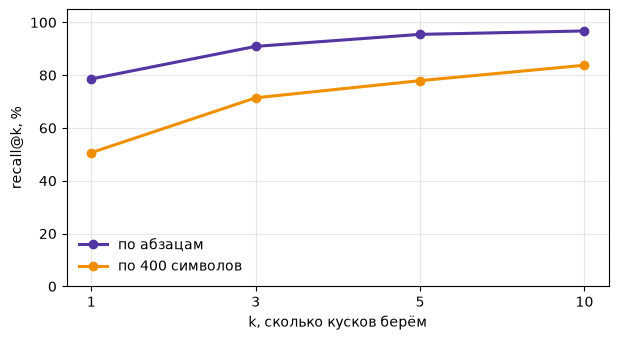

In [14]:
curves = {"по абзацам": recall_curve(line_chunks, line_vecs), "по 400 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig(IMG / "recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

Берём k = 5: при пяти кусках верный находится у 95 % вопросов, а десять кусков добавляют чуть больше процента ценой вдвое большего контекста.